# PyTorch Fundamentals

In this notebook, I will:

- Convert tabular data and into PyTorch tensors
- Create datasets and data loaders
- Build a neural network with 'nn.Module'
- Understand forward propagation
- Calculate loss
- Use backpropagation and an optimizer
- Write a complete training loop
- Monitor training and validation loss
- Evaluate the model on unseen test data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.datasets import load_diabetes
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
def get_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")

device = get_device()

torch.manual_seed(42)
np.random.seed(42)

print("Selected Device: ", device)

Selected Device:  mps


In [3]:
dataset = load_diabetes(as_frame=True)

X = dataset.data.copy()
y = dataset.target.copy()

print("X Shape: ", X.shape)
print("Y Shape: ", y.shape)

X.head()

X Shape:  (442, 10)
Y Shape:  (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
X_train, X_temporary, y_train, y_temporary = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = 42
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temporary,
    y_temporary,
    test_size = 0.50,
    random_state = 42
)

print("Training samples: ", len(X_train))
print("Validation samples: ", len(X_validation))
print("Test samples: ", len(X_test))

Training samples:  309
Validation samples:  66
Test samples:  67


In [5]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_validation_scaled = feature_scaler.transform(X_validation)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
)

y_validation_scaled = target_scaler.transform(
    y_validation.to_numpy().reshape(-1, 1)
)

In [6]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype = torch.float32
)

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype = torch.float32
)

X_validation_tensor = torch.tensor(
    X_validation_scaled,
    dtype = torch.float32
)

y_validation_tensor = torch.tensor(
    y_validation_scaled,
    dtype = torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype = torch.float32
)

In [7]:
print("X train tensor: ", X_train_tensor.shape)
print("y train tensor: ", y_train_tensor.shape)

print("X validation tensor: ", X_validation_tensor.shape)
print("y validation tensor: ", y_validation_tensor.shape)

print("X test tensor: ", X_test_tensor.shape)

X train tensor:  torch.Size([309, 10])
y train tensor:  torch.Size([309, 1])
X validation tensor:  torch.Size([66, 10])
y validation tensor:  torch.Size([66, 1])
X test tensor:  torch.Size([67, 10])


In [8]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

In [9]:
batch_X, batch_y = next(iter(train_loader))

print("Batch X shape: ", batch_X.shape)
print("Batch y shape: ", batch_y.shape)

Batch X shape:  torch.Size([32, 10])
Batch y shape:  torch.Size([32, 1])


In [10]:
class RegressionNetwork(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [11]:
model = RegressionNetwork(
    input_size = X_train_tensor.shape[1]
)

model = model.to(device)

print(model)

RegressionNetwork(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [12]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [16]:
number_of_epochs = 150

training_losses = []
validation_losses = []

for epoch in range(number_of_epochs):
    model.train()

    total_training_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_X)

        loss = loss_function(
            predictions,
            batch_y,
        )

        loss.backward()
        optimizer.step()

        total_training_loss += (
            loss.item() * batch_X.size(0)
        )

    average_training_loss = (
        total_training_loss / len(train_dataset)
    )

    model.eval()

    with torch.no_grad():
        validation_predictions = model(
            X_validation_tensor.to(device)
        )

        validation_loss = loss_function(
            validation_predictions,
            y_validation_tensor.to(device),
        ).item()

    training_losses.append(average_training_loss)
    validation_losses.append(validation_loss)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{number_of_epochs} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f}"
        )

Epoch  20/150 | Train Loss: 0.2185 | Validation Loss: 0.5745
Epoch  40/150 | Train Loss: 0.1946 | Validation Loss: 0.6033
Epoch  60/150 | Train Loss: 0.1712 | Validation Loss: 0.6273
Epoch  80/150 | Train Loss: 0.1524 | Validation Loss: 0.6443
Epoch 100/150 | Train Loss: 0.1352 | Validation Loss: 0.6665
Epoch 120/150 | Train Loss: 0.1176 | Validation Loss: 0.6823
Epoch 140/150 | Train Loss: 0.1041 | Validation Loss: 0.7165


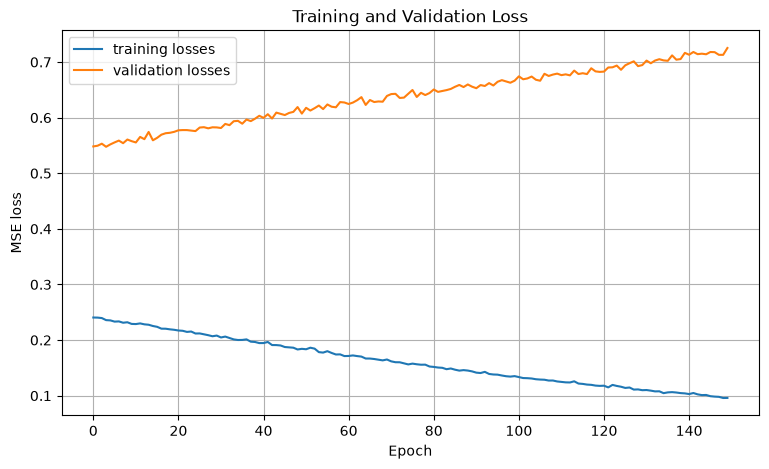

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(
    training_losses,
    label= "training losses"
)

plt.plot(
    validation_losses,
    label = "validation losses"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
model.eval()

with torch.no_grad():
    test_predictions_scaled = model(
        X_test_tensor.to(device)
    )

test_predictions_scaled = (
    test_predictions_scaled.cpu().numpy()
)

In [20]:
test_predictions = (
    target_scaler.inverse_transform(test_predictions_scaled).ravel()
)

actual_values = y_test.to_numpy()

In [22]:
test_mae = mean_absolute_error(
    actual_values, 
    test_predictions
)

test_mse = mean_squared_error(
    actual_values,
    test_predictions
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    actual_values,
    test_predictions
)

print(f"test MAE: {test_mae:.2f}")
print(f"test MSE: {test_mse:.2f}")
print(f"test RMSE: {test_rmse:.2f}")
print(f"test r2: {test_r2:.2f}")

test MAE: 60.93
test MSE: 6213.64
test RMSE: 78.83
test r2: -0.09


In [23]:
results_df = pd.DataFrame({
    "actual": actual_values,
    "predicted": test_predictions
})

results_df["error"] = (
    results_df["actual"] - results_df["predicted"]
)

results_df["absolute_error"] = (
    results_df["error"].abs()
)

results_df.head(10).round(2)

,actual,predicted,error,absolute_error
0,158.0,132.100006,25.90,25.90
1,202.0,88.589996,113.41,113.41
2,113.0,188.940002,-75.94,75.94
3,156.0,303.940002,-147.94,147.94
4,60.0,19.950001,40.05,40.05
5,220.0,173.130005,46.87,46.87
6,129.0,214.789993,-85.79,85.79
7,72.0,164.240005,-92.24,92.24
8,48.0,72.669998,-24.67,24.67
9,99.0,120.919998,-21.92,21.92


In [25]:
results_df.sort_values(
    by="absolute_error",
    ascending=False
).head(10).round(2)

,actual,predicted,error,absolute_error
28,52.0,300.570007,-248.57,248.57
61,88.0,268.559998,-180.56,180.56
44,110.0,284.380005,-174.38,174.38
32,219.0,62.980000,156.02,156.02
3,156.0,303.940002,-147.94,147.94
17,77.0,216.179993,-139.18,139.18
25,90.0,219.710007,-129.71,129.71
41,187.0,58.849998,128.15,128.15
63,258.0,133.559998,124.44,124.44
1,202.0,88.589996,113.41,113.41


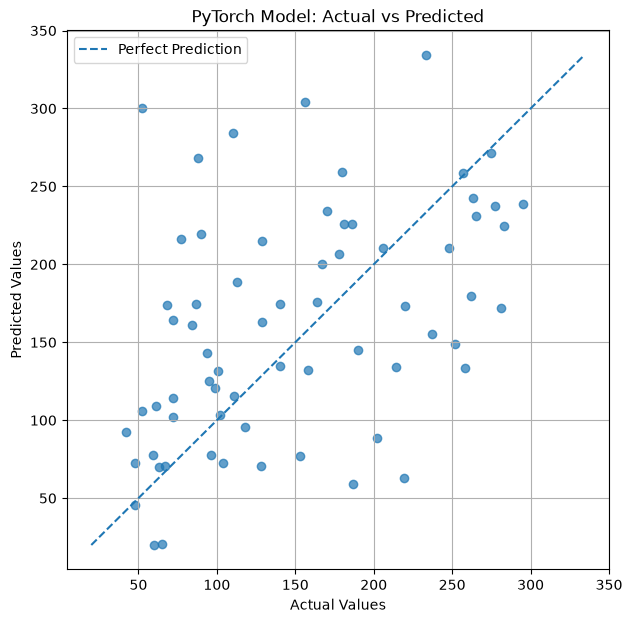

In [26]:
minimum_value = min(
    actual_values.min(),
    test_predictions.min()
)

maximum_value = max(
    actual_values.max(),
    test_predictions.max()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    actual_values,
    test_predictions,
    alpha=0.7
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("PyTorch Model: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

models_directory = project_root / "models"
models_directory.mkdir(exist_ok=True)

model_path = (
    models_directory / "pytorch_regression_model.pth"
)

torch.save(
    model.state_dict(),
    model_path,
)

print("Model saved to:", model_path)

Model saved to: /Users/omurravli/Desktop/pythorch_stock_predict/models/pytorch_regression_model.pth


## Conclusion

In this notebook:

- I converted NumPy data into PyTorch tensors
- I used "TensorDataset" and "DataLoader" to create mini-batches
- I created a neural network by extending "nn.Module"
- I defined an MSE loss function and Adam optimizer
- I wrote a complete PyTorch training loop
- I used backpropagation with "loss.backward()"
- I updated model parameters with "optimizer.step()"
- I monitored training and validation loss
- I evaluated the trained model on unseen test data
- I converted scaled predictions back to their original units
- I saved the trained model parameters

The main PyTorch training cycle is:

1. Clear previous gradients
2. Perform a forward pass
3. Calculate the loss
4. Perform backpropagation
5. Update the model parameters